# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle non-linear relationships, mainly in the context of classification and regression tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how PCA can help with this, but as we discussed this week, (ordinary) PCA is a linear method and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are typically used for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: Palmer Penguins
- A high-dimensional human genotype dataset from the 1000 Genomes Project (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [2]:
# NAME(s) = "Shreyans Jain, Luke Hakso, Thomas Gao"

## 1. Background Reading (20 points)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.
PCA is a method that can capture linear relationships well because it keeps directions with maximum variance, but struggles with non-linear relationships. t-SNE and UMAP can me more effective because they focus on just preserving local relationships in the data, which can help visualize nonlinear patterns in the data.
b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?
t-SNE focuses more closely on preserving local relations than global, which can lead to an inaccurate visulization of global structure, while UMAP uses graph theory to maintain both local and global structure in its representation of the high-dimensional space.


c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.  
t-SNE:
* Perplexity- balances local and global aspects of the data (like a smooth version of n_neighbors)
* n_components - how many dims to reduce to

UMAP:
* n_neighbors- how many points for the algorithm to consider neighbors. The higher this is, the more global structure is preserved.
* min_dist - controls minimun distance between points in the low-dim representation. Higher min-dist preserves global structure better, but makes it harder to see fine variation in local neighborhoods.

YOUR TEXT HERE

## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: Palmer Penguins.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the Palmer Penguins dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

penguins = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")
penguins.head()

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins_clean = penguins.dropna(subset=features + ["species"]).reset_index(drop=True)
print(f"{len(penguins)} rows loaded, {len(penguins_clean)} kept after dropping NaNs")

X = penguins_clean[features].values
species = penguins_clean["species"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("shape:", X_scaled.shape)
print("means:", X_scaled.mean(axis=0).round(3))
print("stds :", X_scaled.std(axis=0).round(3))
pd.DataFrame(X_scaled, columns=features).head()

344 rows loaded, 342 kept after dropping NaNs
shape: (342, 4)
means: [ 0.  0. -0.  0.]
stds : [1. 1. 1. 1.]


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,-1.324737,1.089724,-0.563715,-0.938776
4,-0.847812,1.748985,-0.777373,-0.689020


b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

*N.B.* You may need to first install `UMAP-learn`. Follow the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html) for that.

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PCA explained variance ratio: [0.688 0.193] | total: 0.882


c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


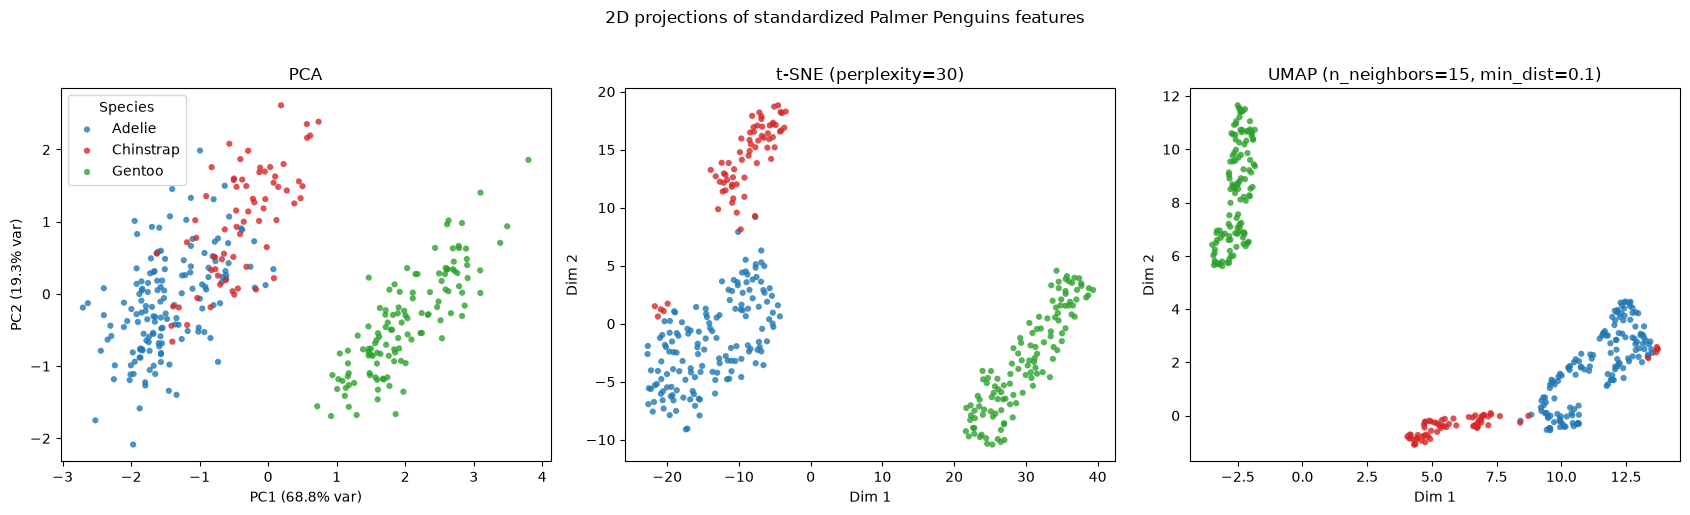

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

RANDOM_STATE = 42
species_order = ["Adelie", "Chinstrap", "Gentoo"]
palette = {"Adelie": "#1f77b4", "Chinstrap": "#d62728", "Gentoo": "#2ca02c"}

def scatter_by_species(ax, emb, title, xlabel="Dim 1", ylabel="Dim 2"):
    for sp in species_order:
        mask = species == sp
        ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.8,
                   c=palette[sp], label=sp, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
print("PCA explained variance ratio:", evr.round(3), "| total:", evr.sum().round(3))

emb_tsne = TSNE(n_components=2, perplexity=30, init="pca",
                learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X_scaled)

emb_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
scatter_by_species(axes[0], emb_pca, "PCA",
                   f"PC1 ({evr[0]*100:.1f}% var)", f"PC2 ({evr[1]*100:.1f}% var)")
scatter_by_species(axes[1], emb_tsne, "t-SNE (perplexity=30)")
scatter_by_species(axes[2], emb_umap, "UMAP (n_neighbors=15, min_dist=0.1)")
axes[0].legend(title="Species")
plt.suptitle("2D projections of standardized Palmer Penguins features", y=1.02)
plt.tight_layout()
plt.show()

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


PCA spots Gentoo right away. It sits off on the right along PC1, with a clean boundary against everything else. PC1 holds 68.8% of the variance and PC2 another 19.3%, so we're looking at 88.1% of the data in one picture. That matches the raw measurements. Gentoos are the big ones. Long flippers, heavy bodies, fairly shallow bills. There's one strong direction in the data that pulls them out. Adelie and Chinstrap are the problem. They genuinely overlap. A good share of the Chinstrap points sit right inside the Adelie cloud around the middle of the plot, and no straight line is getting between them. Those two are nearly identical in flipper length, body mass and bill depth. Bill length is the only real difference. PCA won't hand one feature its own axis, so that difference gets buried inside components built around overall size. t-SNE handles it better. At perplexity 30 we get three compact clusters. Gentoo far off to the right. Adelie and Chinstrap clearly apart, with maybe one stray point near the boundary instead of dozens. That's the whole point of t-SNE. It only cares about keeping close points close, and it'll pull apart groups that were merely sitting next to each other. The catch is that the gaps between clusters don't mean anything. UMAP lands in roughly the same place. Three clean clusters at n_neighbors 15. Gentoo alone up on the left, Adelie and Chinstrap down on the right with a clear gap between them. We expected UMAP's global layout to beat t-SNE's here. It didn't. Both put Gentoo far from the other two and kept Adelie and Chinstrap as neighbors, which is the arrangement that matches the biology. On this dataset we can't tell them apart on that basis. So for splitting these three species, t-SNE and UMAP are about tied and both clearly beat PCA. PCA still wins on interpretation. It's the only one where the axes mean something and where we can say we're seeing 88.1% of the variance. That matters when you have to explain a figure to someone. We should be upfront about the limits here. This is a four-feature dataset where the species are close to linearly separable already. The non-linear methods aren't being pushed. We'd expect a much bigger gap on the genotype data in Section 3, where there are thousands of features instead of four.

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.
- Keep `random_state` fixed across all runs so that differences between projections are due primarily to changes in the hyperparameters rather than random initialization.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

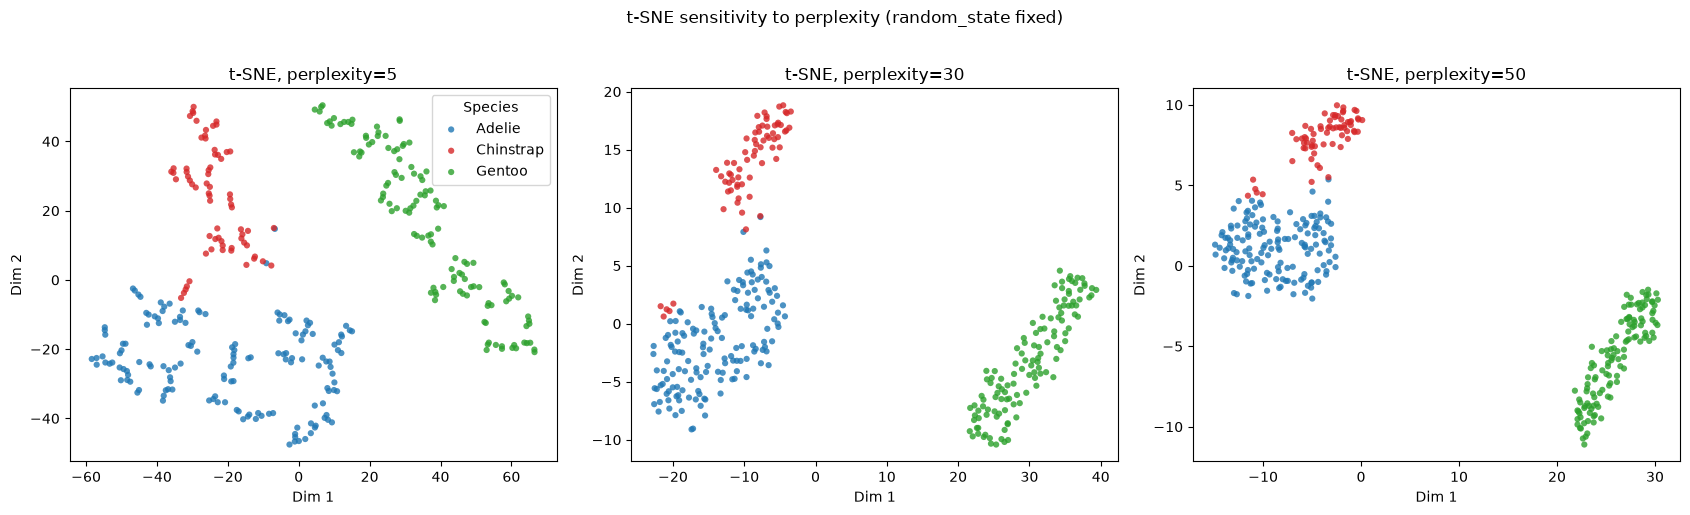

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Us

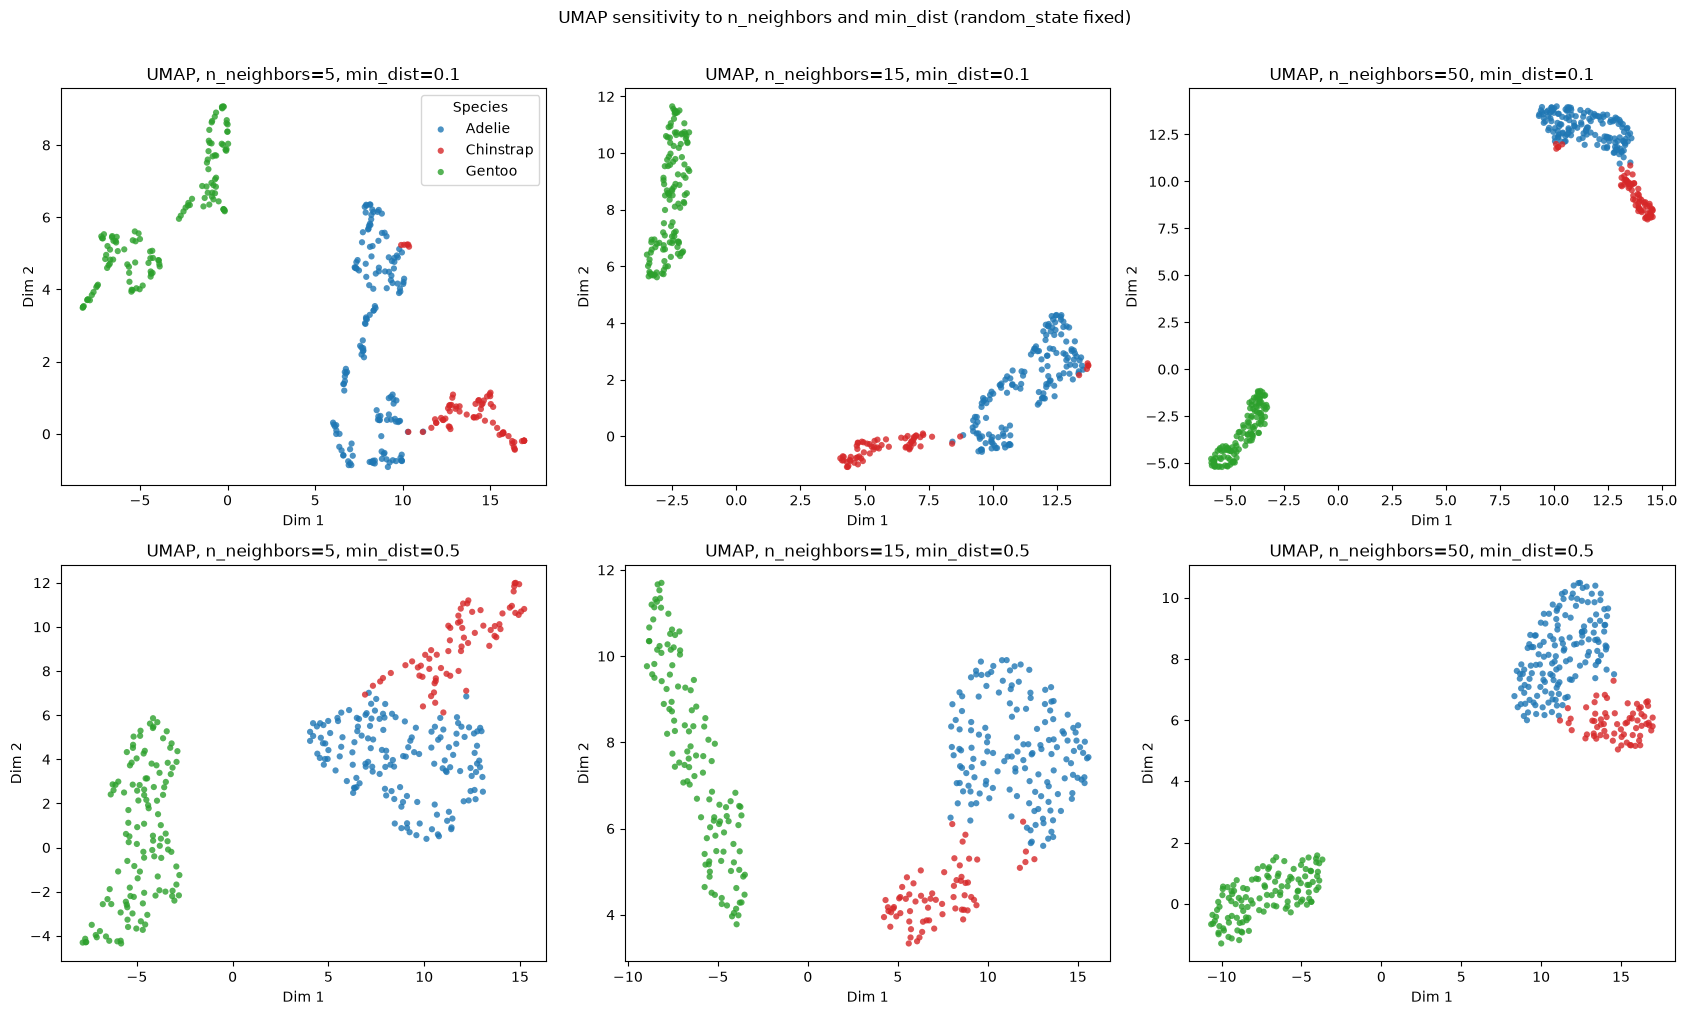

In [ ]:
perplexities = [5, 30, 50]
n_neighbors_list = [5, 15, 50]
min_dists = [0.1, 0.5]

fig, axes = plt.subplots(1, len(perplexities), figsize=(17, 5))
for ax, p in zip(axes, perplexities):
    emb = TSNE(n_components=2, perplexity=p, init="pca",
               learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X_scaled)
    scatter_by_species(ax, emb, f"t-SNE, perplexity={p}")
axes[0].legend(title="Species")
plt.suptitle("t-SNE sensitivity to perplexity (random_state fixed)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(min_dists), len(n_neighbors_list), figsize=(17, 10))
for i, md in enumerate(min_dists):
    for j, nn in enumerate(n_neighbors_list):
        emb = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md,
                        random_state=RANDOM_STATE).fit_transform(X_scaled)
        scatter_by_species(axes[i, j], emb, f"UMAP, n_neighbors={nn}, min_dist={md}")
axes[0, 0].legend(title="Species")
plt.suptitle("UMAP sensitivity to n_neighbors and min_dist (random_state fixed)", y=1.01)
plt.tight_layout()
plt.show()

After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

For t-SNE we tried perplexity 5, 30, and 50 with random_state fixed. At perplexity 5 the clusters get stretched out a lot, the axis range goes from about -60 to 60 while at perplexity 50 it is only about -20 to 30. The species still show up but each one spreads into a loose cloud with a hole in the middle, and Adelie ends up looking like a ring. A few Chinstrap points also end up sitting inside the Adelie cloud, so the separation between those two species is actually worse at low perplexity. This happens because at perplexity 5 each point is only looking at around 5 neighbors, so t-SNE has no information about anything past a point's immediate neighborhood and no reason to keep a species together or to push Chinstrap away from Adelie. Perplexity 30 gave the best looking result, with three compact clusters, Gentoo far off to the right, and only one or two points near the Adelie and Chinstrap border. At perplexity 50 the plot looks similar but everything contracts toward the middle and Adelie and Chinstrap move closer together, almost touching along the top of the Adelie cluster. Gentoo stays well separated in both cases. For UMAP we tried n_neighbors 5, 15, and 50 with min_dist at 0.1 and 0.5. At n_neighbors=5 with min_dist=0.1 the embedding fragments. Gentoo gets split into two separate pieces that end up far apart, and Adelie turns into a thin stringy chain instead of a blob. This is because the k-nearest neighbor graph is too sparse to stay connected, so UMAP lays out the pieces of one species as if they were unrelated. n_neighbors=15 looked the best, with three clean clusters, Gentoo on the left and Adelie and Chinstrap on the right with a gap between them. At n_neighbors=50 the opposite problem shows up. Gentoo is still on its own but Adelie and Chinstrap merge into one connected group, with Chinstrap only showing up as a fringe along the edge of Adelie. If we only looked at that panel we would probably say there were two species instead of three. min_dist made less of a difference than n_neighbors. Going from 0.1 to 0.5 mostly just changed how tightly the points pack together. At 0.1 the clusters are dense with a lot of empty space around them, and at 0.5 they spread out into looser clouds. The one case where it mattered more was n_neighbors=5, where raising min_dist to 0.5 pulled the two Gentoo fragments back together into a single blob. So min_dist does not change which points are neighbors, but it can change how many clusters it looks like there are.
We would use perplexity 30 for t-SNE and n_neighbors 15 with min_dist 0.1 for UMAP on this dataset. Both are large enough that a 342 point dataset does not fragment and small enough that Adelie and Chinstrap stay separate. Perplexity and n_neighbors are basically controlling the same tradeoff between local and global structure, and both failure cases still produce a plot that looks reasonable on its own. Setting the value too low splits up Gentoo and mixes Chinstrap into Adelie, and setting it too high merges Adelie and Chinstrap, and in neither case does the plot tell you anything is wrong. That is why we think running a sweep like this is better than just going with the default.

## 3. Apply to Real Data (1000 Genomes Subset) (25 points)

Your goal in this section is to try to create a figure similar to Figure 1 of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the 1000 Genomes Project.

To do so, complete the following steps:

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual. 

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

In [6]:
# YOUR CODE HERE

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE